# Analyse globale du dataset de brevets

Ce notebook charge le fichier CSV situe dans le dossier `data`, puis realise une premiere exploration globale : dimensions du dataset, informations de base, nombre de brevets par annee lorsque l'information est disponible, et repartition des pays lorsque le champ existe ou peut etre deduit des identifiants de brevet.

Le fichier pouvant etre volumineux, l'analyse se fait en lecture ligne par ligne afin d'eviter de charger tout le CSV en memoire.

## 1. Chargement et analyse en flux

In [2]:
from collections import Counter
from datetime import datetime
from pathlib import Path
import csv
import sys

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from langdetect import DetectorFactory, LangDetectException, detect_langs
    DetectorFactory.seed = 0
    LANGUAGE_DETECTION_AVAILABLE = True
except ImportError:
    LANGUAGE_DETECTION_AVAILABLE = False

DATA_PATH_CANDIDATES = [
    Path("../../data/patent_analysis_data.csv"),
    Path("../data/patent_analysis_data.csv"),
    Path("data/patent_analysis_data.csv"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])

# Certaines colonnes texte peuvent etre tres longues dans les brevets.
field_size_limit = sys.maxsize
while True:
    try:
        csv.field_size_limit(field_size_limit)
        break
    except OverflowError:
        field_size_limit = field_size_limit // 10

UNIQUE_LIMIT_PER_COLUMN = 10_000
PREVIEW_LIMIT = 3
ABSTRACT_BATCH_SIZE = 1_000
LANGUAGE_TEXT_LIMIT = 4_000
MISSING_TEXT_MARKERS = {
    "abstract not found",
    "claims not found",
    "claim not found",
    "description not found",
    "title not found",
    "not found",
}

def find_column(columns, possible_names):
    normalized_columns = {column.strip().lower(): column for column in columns}
    for name in possible_names:
        if name.lower() in normalized_columns:
            return normalized_columns[name.lower()]
    return None

def extract_year(value):
    value = str(value or "").strip()
    if not value:
        return None
    if len(value) >= 4 and value[:4].isdigit():
        return value[:4]
    for date_format in ("%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y"):
        try:
            return str(datetime.strptime(value, date_format).year)
        except ValueError:
            pass
    return None

def truncate_value(value, limit=120):
    value = str(value or "")
    return value[:limit] + "..." if len(value) > limit else value

def is_missing_value(value):
    normalized_value = str(value or "").strip().lower()
    return not normalized_value or normalized_value in MISSING_TEXT_MARKERS

def detect_english_abstract(value):
    text = str(value or "").strip()
    if is_missing_value(text) or len(text) < 20:
        return False
    try:
        detections = detect_langs(text[:LANGUAGE_TEXT_LIMIT])
    except LangDetectException:
        return False
    return bool(detections and detections[0].lang == "en")

with DATA_PATH.open("r", encoding="utf-8", newline="") as csv_file:
    reader = csv.DictReader(csv_file)
    columns = reader.fieldnames or []

    row_count = 0
    preview_rows = []
    missing_counts = Counter()
    non_empty_counts = Counter()
    max_lengths = Counter()
    unique_values = {column: set() for column in columns}
    unique_over_limit = set()
    year_counts = Counter()
    country_counts = Counter()

    year_column = find_column(columns, ["year", "annee", "année", "publication year", "priority year"])
    date_column = None if year_column else find_column(columns, ["Publication Date", "Priority Date", "publication_date", "priority_date"])
    year_source = year_column or (f"annee deduite depuis {date_column}" if date_column else None)

    country_column = find_column(columns, ["country", "pays", "country code", "country_code", "jurisdiction"])
    patent_id_column = None if country_column else find_column(columns, ["Patent ID", "patent_id", "publication number", "publication_number"])
    country_source = country_column or (f"code deduit depuis {patent_id_column}" if patent_id_column else None)

    for row in reader:
        row_count += 1

        if len(preview_rows) < PREVIEW_LIMIT:
            preview_rows.append({column: truncate_value(row.get(column, "")) for column in columns})

        for column in columns:
            value = str(row.get(column, "") or "").strip()
            max_lengths[column] = max(max_lengths[column], len(value))

            if is_missing_value(value):
                missing_counts[column] += 1
                continue

            non_empty_counts[column] += 1
            if column not in unique_over_limit:
                unique_values[column].add(value)
                if len(unique_values[column]) > UNIQUE_LIMIT_PER_COLUMN:
                    unique_values[column].clear()
                    unique_over_limit.add(column)

        if year_column:
            year = str(row.get(year_column, "") or "").strip()
        elif date_column:
            year = extract_year(row.get(date_column))
        else:
            year = None
        if year:
            year_counts[year] += 1

        if country_column:
            country = str(row.get(country_column, "") or "").strip().upper()
        elif patent_id_column:
            patent_id = str(row.get(patent_id_column, "") or "").strip().upper()
            prefix = patent_id.split("-", 1)[0]
            country = prefix if prefix.isalpha() and 2 <= len(prefix) <= 3 else None
        else:
            country = None
        if country:
            country_counts[country] += 1

print(f"Fichier charge : {DATA_PATH}")
print(f"Nombre de lignes : {row_count:,}".replace(",", " "))
print(f"Nombre de colonnes : {len(columns)}")
if not MATPLOTLIB_AVAILABLE:
    print("Graphiques non disponibles : installez matplotlib avec `pip install -r requirements.txt`.")
if not LANGUAGE_DETECTION_AVAILABLE:
    print("Filtrage anglais non disponible : installez langdetect avec `pip install -r requirements.txt`.")


Fichier charge : ../../data/patent_analysis_data.csv
Nombre de lignes : 23 339
Nombre de colonnes : 9


## 2. Informations de base

In [3]:
print("Colonnes disponibles :")
for index, column in enumerate(columns, start=1):
    print(f"{index}. {column}")

print("\nApercu des 3 premieres lignes :")
for row in preview_rows:
    print(row)

Colonnes disponibles :
1. Patent ID
2. Title
3. Assignee
4. Priority Date
5. Publication Date
6. Abstract
7. Claims
8. Description
9. Result Link

Apercu des 3 premieres lignes :
{'Patent ID': 'CN-110473636-B', 'Title': 'Intelligent medical advice recommendation method and system based on deep learning ', 'Assignee': '山东众阳健康科技集团有限公司', 'Priority Date': '2019-08-22', 'Publication Date': '2020-09-22', 'Abstract': 'The disclosure provides an intelligent medical advice recommendation method and system based on deep learning, and the i...', 'Claims': 'Claims (8)\n\n \n1. The intelligent medical advice recommendation method based on deep learning is characterized by compris...', 'Description': 'Description\n\nIntelligent medical advice recommendation method and system based on deep learning\n\nTechnical Field\nThe dis...', 'Result Link': 'https://patents.google.com/patent/CN110473636B/en'}
{'Patent ID': 'US-11850021-B2', 'Title': 'Dynamic self-learning medical image method and system ', 'Assi

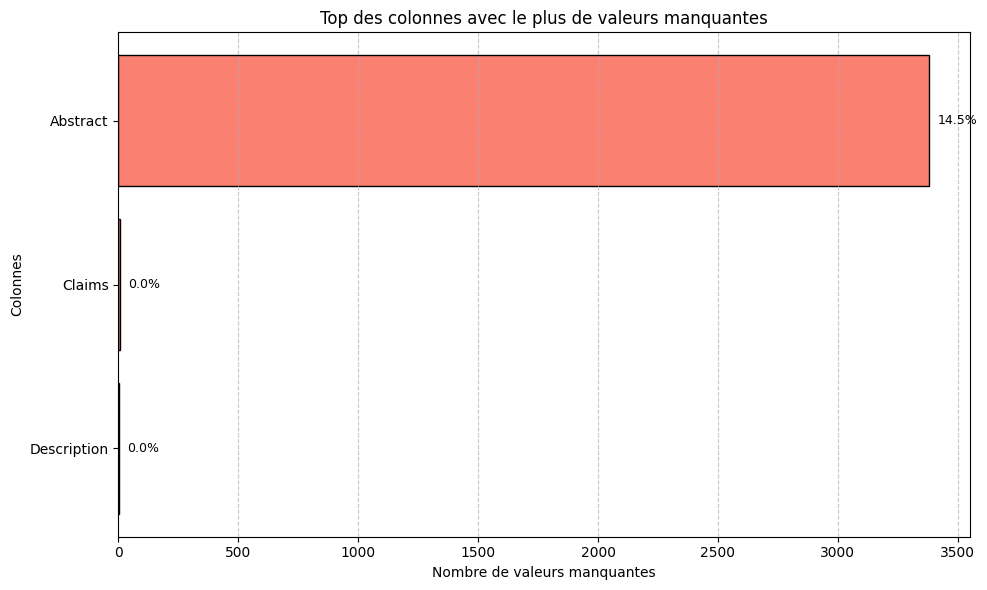

In [4]:
if not MATPLOTLIB_AVAILABLE:
    print("matplotlib n'est pas installe. Lancez `pip install -r requirements.txt` pour generer ce graphique.")
elif missing_counts:
    # 1. Préparation : Tri par nombre de valeurs manquantes (du plus grand au plus petit)
    # On transforme le dictionnaire en liste de tuples triée
    sorted_missing = sorted(missing_counts.items(), key=lambda x: x[1], reverse=True)
    
    columns = [item[0] for item in sorted_missing]
    counts = [item[1] for item in sorted_missing]
    
    # Calcul des pourcentages pour l'affichage
    percentages = [(count / row_count * 100) if row_count else 0 for count in counts]

    # 2. Création du graphique
    plt.figure(figsize=(10, 6))
    bars = plt.barh(columns, counts, color='salmon', edgecolor='black')

    # 3. Personnalisation
    plt.title("Top des colonnes avec le plus de valeurs manquantes")
    plt.xlabel("Nombre de valeurs manquantes")
    plt.ylabel("Colonnes")
    plt.gca().invert_yaxis() # Met la valeur la plus grande (le 'top') en haut
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # Ajout des pourcentages au bout des barres pour plus de clarté
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + (max(counts) * 0.01), 
                 bar.get_y() + bar.get_height()/2, 
                 f"{percentages[i]:.1f}%", 
                 va='center', fontsize=9)

    plt.tight_layout()

    plt.show()
else:
    print("Aucune donnée manquante détectée.")

## 3. Nombre de brevets par annee

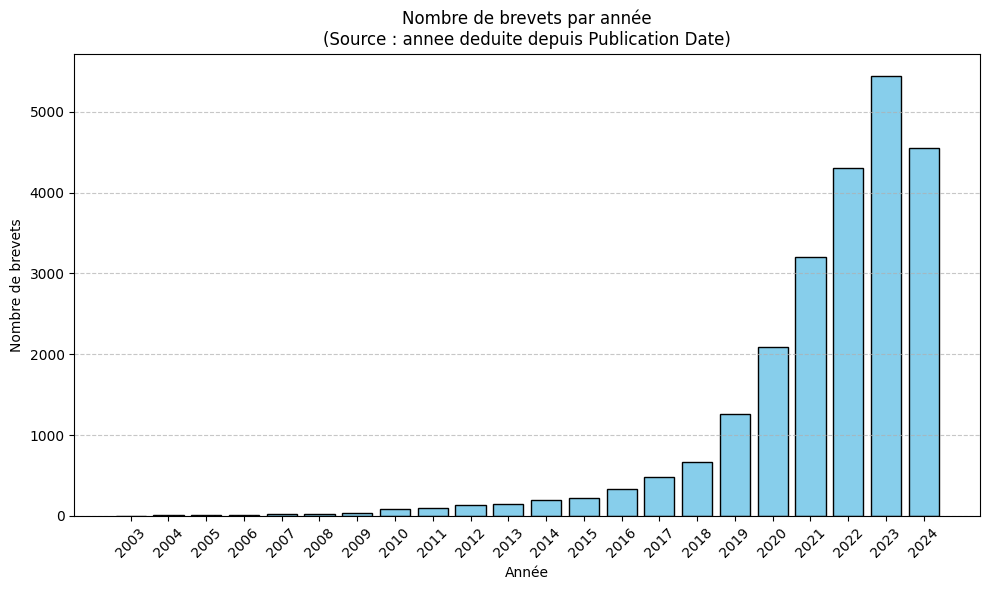

In [5]:
if not MATPLOTLIB_AVAILABLE:
    print("matplotlib n'est pas installe. Lancez `pip install -r requirements.txt` pour generer ce graphique.")
elif year_counts:
    # 1. Préparation des données triées
    sorted_data = sorted(year_counts.items())
    years = [str(item[0]) for item in sorted_data] # Conversion en string pour l'axe x
    counts = [item[1] for item in sorted_data]

    # 2. Création du graphique
    plt.figure(figsize=(10, 6))
    plt.bar(years, counts, color='skyblue', edgecolor='black')

    # 3. Personnalisation
    plt.title(f"Nombre de brevets par année\n(Source : {year_source})")
    plt.xlabel("Année")
    plt.ylabel("Nombre de brevets")
    plt.xticks(rotation=45) # Rotation pour éviter le chevauchement si beaucoup d'années
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Ajustement automatique pour ne pas couper les labels
    plt.tight_layout()

    plt.show()
else:
    print("Aucun champ année/date exploitable n'a été trouvé dans le dataset.")

## 4. Repartition des pays

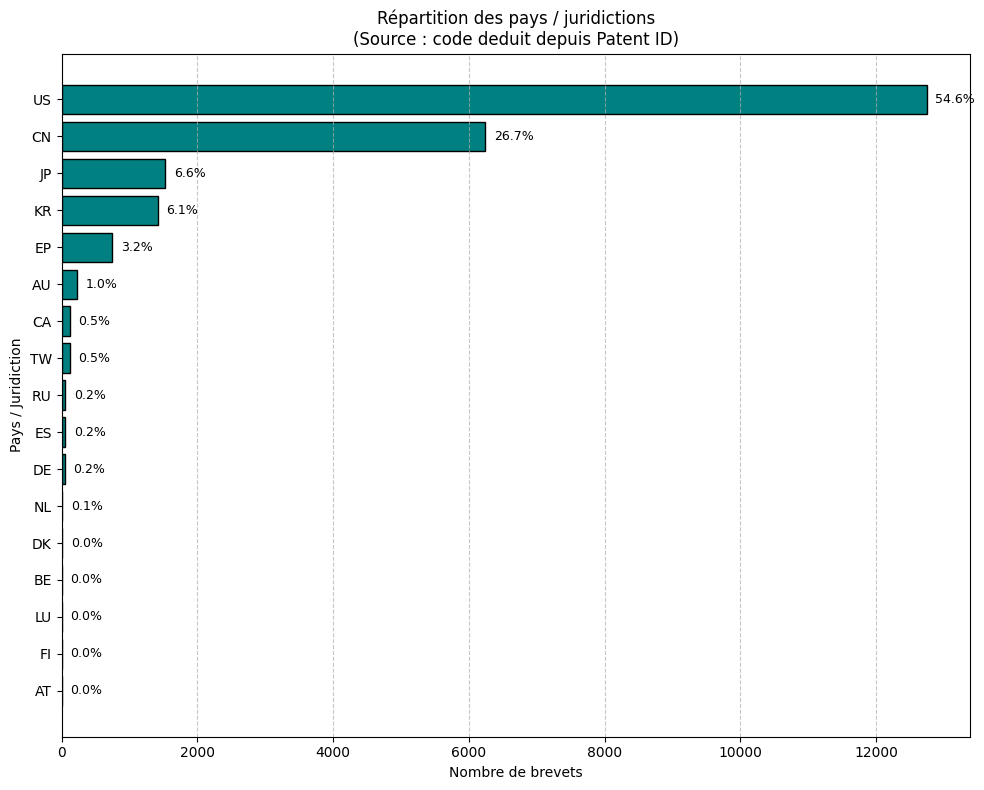

In [6]:
if not MATPLOTLIB_AVAILABLE:
    print("matplotlib n'est pas installe. Lancez `pip install -r requirements.txt` pour generer ce graphique.")
elif country_counts:
    # 1. Préparation des données
    # most_common() renvoie les éléments triés du plus grand au plus petit
    # On inverse la liste [::-1] pour que le plus grand apparaisse en haut du graphique
    data = country_counts.most_common()[::-1]
    countries = [item[0] for item in data]
    counts = [item[1] for item in data]
    
    # 2. Création du graphique
    plt.figure(figsize=(10, 8)) # Taille ajustée pour laisser de la place aux noms des pays
    plt.barh(countries, counts, color='teal', edgecolor='black')
    
    # 3. Personnalisation
    plt.title(f"Répartition des pays / juridictions\n(Source : {country_source})")
    plt.xlabel("Nombre de brevets")
    plt.ylabel("Pays / Juridiction")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Ajout des pourcentages sur le côté des barres (optionnel mais très utile)
    for i, v in enumerate(counts):
        percentage = (v / row_count * 100) if row_count else 0
        plt.text(v + (max(counts) * 0.01), i, f"{percentage:.1f}%", va='center', fontsize=9)
    
    plt.tight_layout()

    plt.show()
else:
    print("Aucun champ pays n'a été trouvé, et aucun code pays n'a pu être déduit des identifiants de brevet.")

## 5. Filtrage des brevets avec abstract en anglais par lots

In [7]:
if not LANGUAGE_DETECTION_AVAILABLE:
    print("La librairie langdetect n'est pas installee. Lancez `pip install -r requirements.txt`, puis reexecutez le notebook.")
else:
    abstract_column = find_column(columns, ["Abstract", "abstract"])
    if not abstract_column:
        print("Aucune colonne Abstract n'a ete trouvee.")
    else:
        batch_stats = []
        english_abstract_year_counts = Counter()
        english_abstract_country_counts = Counter()
        totals = Counter()

        current_batch = Counter()
        current_batch_index = 1
        current_batch_start = 1

        def close_batch(end_row):
            if current_batch["total"] == 0:
                return
            stats = {
                "batch": current_batch_index,
                "start_row": current_batch_start,
                "end_row": end_row,
                "total": current_batch["total"],
                "empty_abstract": current_batch["empty_abstract"],
                "checked_abstract": current_batch["checked_abstract"],
                "english_abstract": current_batch["english_abstract"],
                "rejected_not_english": current_batch["rejected_not_english"],
            }
            batch_stats.append(stats)
            print(
                f"Lot {stats['batch']} | lignes {stats['start_row']}-{stats['end_row']} | "
                f"total {stats['total']:,} | vides {stats['empty_abstract']:,} | "
                f"anglais gardes {stats['english_abstract']:,} | "
                f"non anglais/indetermines {stats['rejected_not_english']:,}"
                .replace(",", " ")
            )

        with DATA_PATH.open("r", encoding="utf-8", newline="") as csv_file:
            reader = csv.DictReader(csv_file)
            for row_number, row in enumerate(reader, start=1):
                abstract = row.get(abstract_column, "")
                current_batch["total"] += 1
                totals["total"] += 1

                if is_missing_value(abstract):
                    current_batch["empty_abstract"] += 1
                    totals["empty_abstract"] += 1
                else:
                    current_batch["checked_abstract"] += 1
                    totals["checked_abstract"] += 1

                    if detect_english_abstract(abstract):
                        current_batch["english_abstract"] += 1
                        totals["english_abstract"] += 1

                        if date_column:
                            year = extract_year(row.get(date_column))
                            if year:
                                english_abstract_year_counts[year] += 1

                        if country_column:
                            country = str(row.get(country_column, "") or "").strip().upper()
                        elif patent_id_column:
                            patent_id = str(row.get(patent_id_column, "") or "").strip().upper()
                            prefix = patent_id.split("-", 1)[0]
                            country = prefix if prefix.isalpha() and 2 <= len(prefix) <= 3 else None
                        else:
                            country = None
                        if country:
                            english_abstract_country_counts[country] += 1
                    else:
                        current_batch["rejected_not_english"] += 1
                        totals["rejected_not_english"] += 1

                if current_batch["total"] >= ABSTRACT_BATCH_SIZE:
                    close_batch(row_number)
                    current_batch = Counter()
                    current_batch_index += 1
                    current_batch_start = row_number + 1

            close_batch(totals["total"])

        kept_rate = totals["english_abstract"] / totals["total"] * 100 if totals["total"] else 0
        empty_rate = totals["empty_abstract"] / totals["total"] * 100 if totals["total"] else 0
        rejected_rate = totals["rejected_not_english"] / totals["total"] * 100 if totals["total"] else 0

        print("\nSynthese finale :")
        print(f"Brevets parcourus : {totals['total']:,}".replace(",", " "))
        print(f"Abstracts vides retires : {totals['empty_abstract']:,} ({empty_rate:.2f}%)".replace(",", " "))
        print(f"Abstracts non vides verifies : {totals['checked_abstract']:,}".replace(",", " "))
        print(f"Brevets gardes avec abstract anglais : {totals['english_abstract']:,} ({kept_rate:.2f}%)".replace(",", " "))
        print(f"Brevets rejetes non anglais ou indetermines : {totals['rejected_not_english']:,} ({rejected_rate:.2f}%)".replace(",", " "))


Lot 1 | lignes 1-1000 | total 1 000 | vides 125 | anglais gardes 874 | non anglais/indetermines 1
Lot 2 | lignes 1001-2000 | total 1 000 | vides 108 | anglais gardes 891 | non anglais/indetermines 1
Lot 3 | lignes 2001-3000 | total 1 000 | vides 131 | anglais gardes 867 | non anglais/indetermines 2
Lot 4 | lignes 3001-4000 | total 1 000 | vides 157 | anglais gardes 843 | non anglais/indetermines 0
Lot 5 | lignes 4001-5000 | total 1 000 | vides 118 | anglais gardes 881 | non anglais/indetermines 1
Lot 6 | lignes 5001-6000 | total 1 000 | vides 117 | anglais gardes 880 | non anglais/indetermines 3
Lot 7 | lignes 6001-7000 | total 1 000 | vides 144 | anglais gardes 854 | non anglais/indetermines 2
Lot 8 | lignes 7001-8000 | total 1 000 | vides 124 | anglais gardes 875 | non anglais/indetermines 1
Lot 9 | lignes 8001-9000 | total 1 000 | vides 139 | anglais gardes 860 | non anglais/indetermines 1
Lot 10 | lignes 9001-10000 | total 1 000 | vides 137 | anglais gardes 862 | non anglais/indete

### Graphique final du filtrage par lots

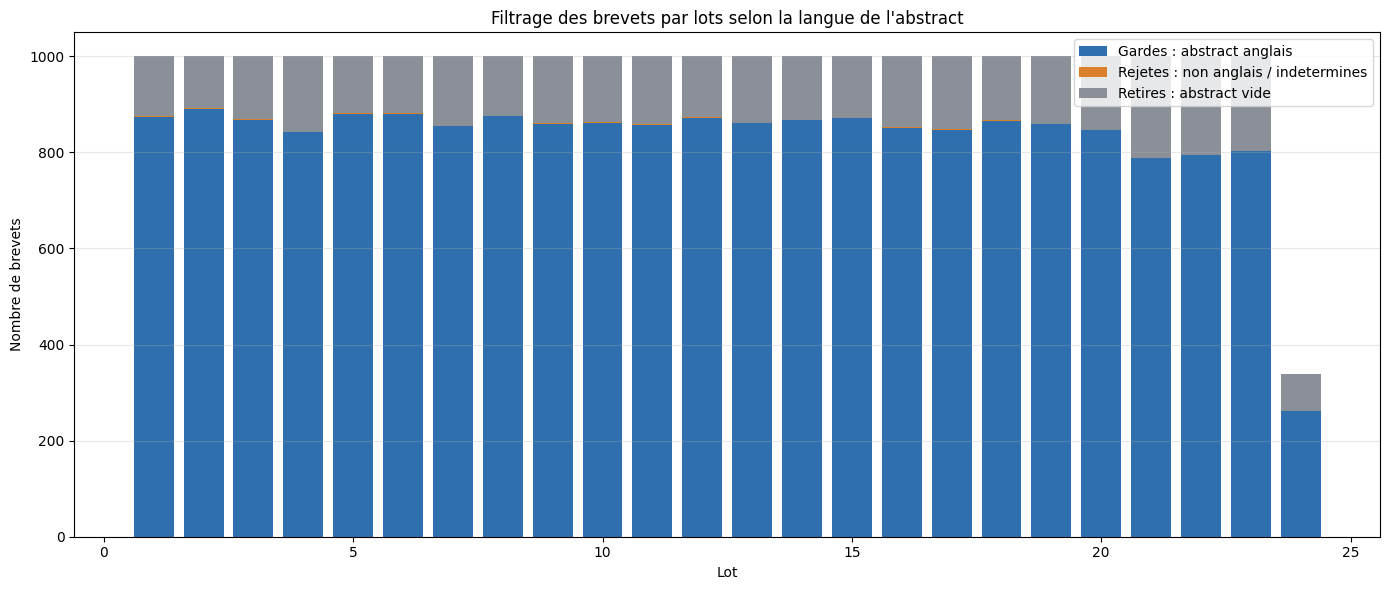

In [8]:
if not LANGUAGE_DETECTION_AVAILABLE:
    print("Installez langdetect pour calculer les donnees du graphique.")
elif not MATPLOTLIB_AVAILABLE:
    print("Installez matplotlib pour afficher le graphique.")
elif not batch_stats:
    print("Aucune statistique par lot disponible. Executez d'abord la cellule de filtrage par lots.")
else:
    batch_numbers = [stats["batch"] for stats in batch_stats]
    empty_counts = [stats["empty_abstract"] for stats in batch_stats]
    english_counts = [stats["english_abstract"] for stats in batch_stats]
    rejected_counts = [stats["rejected_not_english"] for stats in batch_stats]

    plt.figure(figsize=(14, 6))
    plt.bar(batch_numbers, english_counts, label="Gardes : abstract anglais", color="#2F6FAD")
    plt.bar(batch_numbers, rejected_counts, bottom=english_counts, label="Rejetes : non anglais / indetermines", color="#D9822B")
    bottom_empty = [english + rejected for english, rejected in zip(english_counts, rejected_counts)]
    plt.bar(batch_numbers, empty_counts, bottom=bottom_empty, label="Retires : abstract vide", color="#8A8F98")

    plt.title("Filtrage des brevets par lots selon la langue de l'abstract")
    plt.xlabel("Lot")
    plt.ylabel("Nombre de brevets")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
